In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [2]:
import glob
import pandas as pd
import numpy as np

In [3]:
arquivos = glob.glob('/kaggle/input/brazilian-ecommerce/*')

In [4]:
T = pd.read_csv(arquivos[0])
print(arquivos[0].split('/')[-1])
print(T.columns)
print(T.shape)

olist_customers_dataset.csv
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
(99441, 5)


In [5]:
for a in arquivos:
  T = pd.read_csv(a)
  print(a.split('/')[-1])
  print(T.columns)
  print(T.shape)

olist_customers_dataset.csv
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
(99441, 5)
olist_sellers_dataset.csv
Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')
(3095, 4)
olist_order_reviews_dataset.csv
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
(99224, 7)
olist_order_items_dataset.csv
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
(112650, 7)
olist_products_dataset.csv
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')
(32951, 9)
oli

In [6]:
D = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')

In [7]:
G = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv')
S = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv')
C = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv')

In [8]:
print(G['geolocation_zip_code_prefix'].nunique(),
S['seller_zip_code_prefix'].nunique(),
C['customer_zip_code_prefix'].nunique())

19015 2246 14994


In [9]:
pd.concat((G['geolocation_zip_code_prefix'],
           S['seller_zip_code_prefix'],
           C['customer_zip_code_prefix'])).nunique()

19177

<Axes: >

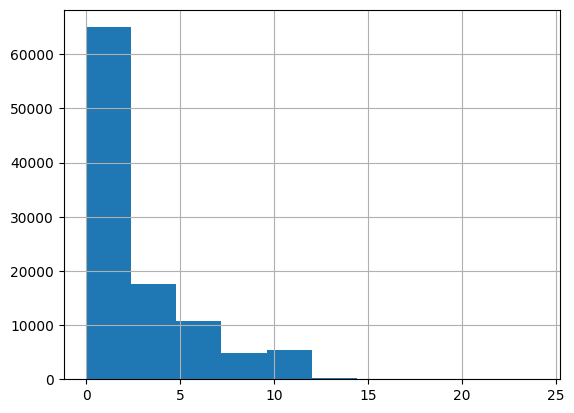

In [10]:
D['payment_installments'].hist()

In [11]:
D[['payment_type','payment_value']].groupby('payment_type').agg('count')

,payment_value
payment_type,
boleto,19784
credit_card,76795
debit_card,1529
not_defined,3
voucher,5775


In [12]:
# 15. Quantos vendedores distintos existem?
num_sellers = S['seller_id'].nunique()
print("Número de vendedores distintos:", num_sellers)


Número de vendedores distintos: 3095


In [13]:
# 16. Qual a porcentagem de vendas feitas com cartão de crédito?

total_pagamentos = len(D)
total_cartao = (D['payment_type'] == 'credit_card').sum()

percentual_cartao = total_cartao / total_pagamentos * 100

print(f"Porcentagem de vendas com cartão de crédito: {percentual_cartao:.2f}%")


Porcentagem de vendas com cartão de crédito: 73.92%


In [14]:
reviews = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv')
items   = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv')

In [15]:
# Merge: reviews -> items -> products
df_rev = reviews.merge(items, on='order_id', how='left')
df_rev_cat = df_rev.merge(products[['product_id','product_category_name']], on='product_id', how='left')

In [16]:
# Média de score por categoria
media_scores = df_rev_cat.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)

# 20. Qual a média de review_score por categoria de produto?
print(media_scores)

product_category_name
cds_dvds_musicais                                4.642857
fashion_roupa_infanto_juvenil                    4.500000
livros_interesse_geral                           4.446266
construcao_ferramentas_ferramentas               4.444444
flores                                           4.419355
                                                   ...   
moveis_escritorio                                3.493183
pc_gamer                                         3.333333
portateis_cozinha_e_preparadores_de_alimentos    3.266667
fraldas_higiene                                  3.256410
seguros_e_servicos                               2.500000
Name: review_score, Length: 73, dtype: float64


In [17]:
# Contagem de produtos por categoria
top5 = products['product_category_name'].value_counts().head(5)

# 21. Quais as 5 categorias que mais possuem produtos?
print("Top 5 categorias com mais produtos:")
print(top5)


Top 5 categorias com mais produtos:
product_category_name
cama_mesa_banho          3029
esporte_lazer            2867
moveis_decoracao         2657
beleza_saude             2444
utilidades_domesticas    2335
Name: count, dtype: int64


In [18]:
# Comentários não vazios
reviews = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv')

num_comentarios = reviews[['review_comment_title','review_comment_message']].notna().any(axis=1).sum()

# 22. Quantos comentários existem na base?
print("Número total de comentários:", num_comentarios)


Número total de comentários: 42706
